# The Voluntary Classroom Questionnaire

The Voluntary Classroom Questionnaire (VCQ) dataset was developed to offer students a manageable and user-friendly resource for statistical analysis. It consists of 154 variables, including demographic questions and multiple-item measures in areas such as school, work, friends and family, and well-being. The data was collected from 2015 to 2019 in Dr. Trinidad’s Introduction to Statistics for the Social Sciences (SOC 201) and Quantitative Research Methods (SOC 360) classes. Approximately 543 students participated in the VCQ over the five-year collection period.

The VCQ was administered as an in-class activity for educational purposes. Students were invited to complete a 23-page paper-pencil survey, but submission was not mandatory. They were informed that they could skip any question they found uncomfortable and could stop at any time. To ensure anonymity, students were told not to include their names and to skip or fabricate values for any demographic variables that might be outliers. Students who chose to submit their completed questionnaire did so after Dr. Trinidad left the room. They were then instructed to randomly mix their submitted questionnaires with those from other classes and previous semesters.

Participation in the VCQ offered several educational benefits to students: (1) It provided students with firsthand experience of participating in a survey, (2) It helped students understand the processes of data entry and data cleaning, as they were required to practice both, and (3) It provided students with a dataset for practicing statistical analysis. It’s important to note that the VCQ was not designed for publication analysis, as students fabricated some of their responses to demographic questions to maintain anonymity.

https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit

## Data Preparation

CSV file: https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv

In [55]:
#Collect data into a DataFrame object
import pandas as pd
raw_df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv')

In [56]:
#Finding the number of rows and number of columns
raw_df.shape

(543, 154)

There are 543 rows and 154 columns.

In [57]:
#Provides summary of the columns in the DataFrame
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Columns: 154 entries, id to satisfaction_performancework
dtypes: float64(134), int64(20)
memory usage: 653.4 KB


Out of the 154 columns, 134 are of float64 data type and 20 are of int64 data type. 

In [58]:
#Show the first 5 rows of the DataFrame
raw_df.head()

,id,demo_gender,demo_age,demo_relationshipstatus01,demo_children,demo_classstanding,demo_units,demo_gpa,demo_employed01,demo_employed02,...,coworkers_respect,coworkers_friends,coworkers_argue,coworkers_like,wis_time,wis_tired,satisfaction_performanceschool,siw_time,siw_tired,satisfaction_performancework
0,1,1,19.00,1,2.00,2,15.00,3.15,1.00,1,...,4.00,5.00,5.00,5.00,4.00,4.00,3.00,3.00,3.00,2.00
1,2,2,26.00,2,2.00,3,14.00,3.30,1.00,1,...,6.00,6.00,1.00,6.00,5.00,5.00,4.00,5.00,5.00,4.00
2,3,1,NaN,1,2.00,3,15.00,3.11,2.00,2,...,NaN,NaN,NaN,NaN,3.00,2.00,NaN,2.00,3.00,3.00
3,4,2,NaN,1,2.00,2,17.00,3.40,2.00,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2,19.00,1,2.00,2,13.00,3.00,2.00,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filtering

In [59]:
#The items parameter takes a list of column names
gender_age_df = raw_df.filter(items=['demo_gender', 'demo_age']).copy()
gender_age_df.head()

,demo_gender,demo_age
0,1,19.00
1,2,26.00
2,1,NaN
3,2,NaN
4,2,19.00


In [60]:
#The like parameter looks for all columns whose names include 'employ'
employ_df = raw_df.filter(like='employ').copy()
employ_df.columns

Index(['demo_employed01', 'demo_employed02', 'demo_employed03',
       'demo_employed04'],
      dtype='object')

In [61]:
#The regex parameter looks for all columns whose names start with demo
demo_df = raw_df.filter(regex='^demo').copy()
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   demo_gender                543 non-null    int64  
 1   demo_age                   534 non-null    float64
 2   demo_relationshipstatus01  543 non-null    int64  
 3   demo_children              542 non-null    float64
 4   demo_classstanding         543 non-null    int64  
 5   demo_units                 539 non-null    float64
 6   demo_gpa                   518 non-null    float64
 7   demo_employed01            542 non-null    float64
 8   demo_employed02            543 non-null    int64  
 9   demo_employed03            388 non-null    float64
 10  demo_incomehousehold       332 non-null    float64
 11  demo_incomepersonal        366 non-null    float64
 12  demo_politics              505 non-null    float64
 13  demo_religion              539 non-null    float64

In [62]:
#Creating a new DataFrame object that contains two columns
#Calling the copy function so that any change to the new DataFrame will not affect raw_df
units_gpa_df = raw_df.filter(items=['demo_units', 'demo_gpa']).copy()
#Displaying the first 5 rows of the DataFrame
units_gpa_df.head()

,demo_units,demo_gpa
0,15.00,3.15
1,14.00,3.30
2,15.00,3.11
3,17.00,3.40
4,13.00,3.00


In [63]:
# Using the like parameter to create a new DataFrame object that contains columns whose names include 'coworkers'
#Calling the copy function so that any change to the new DataFrame will not affect raw_df
coworkers_df = raw_df.filter(like='coworkers').copy()
#Displaying the columns of the coworkers_df DataFrame
coworkers_df.columns

Index(['coworkers_trouble', 'coworkers_me', 'coworkers_respect',
       'coworkers_friends', 'coworkers_argue', 'coworkers_like'],
      dtype='object')

In [64]:
# Using the regex parameter to create a new DataFrame object that contains columns whose names start with 'siw'
# Be sure the call the copy function so that any change to the new DataFrame will not affect raw_df
siw_df = raw_df.filter(regex='^siw').copy()
#Displaying the info of the siw_df DataFrame
siw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   siw_time   391 non-null    float64
 1   siw_tired  391 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


### Removing prefix by str accessor

In [65]:
#Removing the prefix 'demo_' from the demographics DataFrame
demo_df.columns = demo_df.columns.str.removeprefix('demo_')
demo_df.head()

,gender,age,relationshipstatus01,children,classstanding,units,gpa,employed01,employed02,employed03,incomehousehold,incomepersonal,politics,religion,relationshipstatus02,employed04
0,1,19.00,1,2.00,2,15.00,3.15,1.00,1,45.00,60000.00,16000.00,NaN,6.00,1.00,1.00
1,2,26.00,2,2.00,3,14.00,3.30,1.00,1,35.00,27000.00,27000.00,4.00,5.00,2.00,1.00
2,1,NaN,1,2.00,3,15.00,3.11,2.00,2,NaN,6000.00,2000.00,4.00,3.00,1.00,NaN
3,2,NaN,1,2.00,2,17.00,3.40,2.00,2,NaN,NaN,NaN,3.00,4.00,1.00,2.00
4,2,19.00,1,2.00,2,13.00,3.00,2.00,2,NaN,NaN,NaN,3.00,3.00,1.00,2.00


In [66]:
#Removing the prefix 'demo_' from the units and gpa DataFrame
units_gpa_df.columns = units_gpa_df.columns.str.removeprefix('demo_')

In [67]:
##Removing the prefix 'coworkers_' from the coworkers DataFrame
coworkers_df.columns = coworkers_df.columns.str.removeprefix('coworkers_')
coworkers_df.head()

,trouble,me,respect,friends,argue,like
0,2.00,2.00,4.00,5.00,5.00,5.00
1,1.00,1.00,6.00,6.00,1.00,6.00
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN


### Descriptive Statistics

In [68]:
#Set float display format to comma as thousand separator and 2 digits after the decimal point
pd.options.display.float_format = '{:,.2f}'.format
demo_df['age'].describe()

count   534.00
mean     21.40
std       2.98
min      18.00
25%      19.00
50%      20.00
75%      22.00
max      35.00
Name: age, dtype: float64

What we know from the descriptive statistics about the students who completed the 'age' portion of the survey:
* The average age for these students was 21.40.
* The youngest student was 18.
* The oldest student was 35.
* A quarter of students were 19 or younger
* Half of students were 20 or younger.
* A quarter of students were 22 or above.

In [69]:
#Calling the describe function to find the descriptive statistics for the 'units' and 'gpa' column.
pd.options.display.float_format = '{:,.2f}'.format
units_gpa_df.describe()

,units,gpa
count,539.00,518.00
mean,13.61,3.23
std,2.48,0.48
min,3.00,1.50
25%,12.00,3.00
50%,13.00,3.21
75%,15.00,3.60
max,22.00,4.00


What we know from the descriptive statistics about the students who completed the 'demo_units' portion of the survey:
* The average units taken by students were 13.61 and the average gpa is 3.23.
* The minimum units taken is 3 units and the minimum gpa is 1.5.
* The maximum units is 22 units and the maximum gpa is 4.0.
* A quarter of students took 12 units or less and a quarter of students had a 3.0 gpa or lower.
* Half of the students were taking 13 units and half the students had a 3.21 gpa.
* A quarter of students were taking 15 units or higher and a quarter of students had a 3.6 gpa or higher.

### Unique and value counts

* The unique() method shows all distinct values in a column
* The value_counts() displays the frequency of each value.

In [70]:
demo_df['gender'].unique()

array([1, 2, 3])

The above result shows that the 'gender' column contains three unique values: 1, 2, and 3.

In [71]:
demo_df['gender'].value_counts()

gender
2    363
1    176
3      4
Name: count, dtype: int64

The above result shows that 362 students responded 2 (Female), 176 students responded 1 (Male), and 4 students responded 3 (Other).

### Unique and value counts for 'age' columns

In [72]:
demo_df['age'].unique()

array([19., 26., nan, 24., 20., 21., 27., 22., 18., 25., 30., 23., 34.,
       28., 29., 32., 35., 31.])

In [73]:
demo_df['age'].value_counts()

age
20.00    134
19.00    111
21.00     87
22.00     40
18.00     31
24.00     30
23.00     29
25.00     21
28.00     12
30.00     10
26.00      8
27.00      8
29.00      7
34.00      2
32.00      2
35.00      1
31.00      1
Name: count, dtype: int64

### Replace function

In [74]:
map = {1:'Yes', 2:'No'}
demo_df['children_text'] = demo_df['children'].replace(map)
demo_df[['children', 'children_text']].tail(10)

,children,children_text
533,2.00,No
534,1.00,Yes
535,2.00,No
536,2.00,No
537,2.00,No
538,2.00,No
539,2.00,No
540,2.00,No
541,2.00,No
542,2.00,No


The above block replaces 1 in demo_df['children'] with "Yes" and 2 with "No". 
* The replace function creates a new column without changing the existing one.

In [75]:
#Using the replace function to change the gender column from 1, 2, 3 into Male, Female, and Other
map = {1:'Male', 2:'Female', 3:'Other'}
demo_df['gender_text'] = demo_df['gender'].replace(map)
#Displaying the last 10 rows of the gender and gender_text columns to verify the change
demo_df[['gender', 'gender_text']].tail(10)

,gender,gender_text
533,1,Male
534,2,Female
535,2,Female
536,2,Female
537,2,Female
538,2,Female
539,2,Female
540,2,Female
541,1,Male
542,1,Male


## Data Preperation 

* Reads the VCQ data from its CSV file into the raw_df DataFrame object
* Creates the demo_df object to contain only the columns for demographic questions
* Removes the prefix 'demo_' from all column names in demo_df.

In [76]:
# Create a new DataFrame object to holds only demographic data
demo_df = raw_df.filter(regex='^demo').copy()
# Remove the 'demo_' prefix from column names
demo_df.columns = demo_df.columns.str.removeprefix('demo_')
# Replace 1 - 4 with respective class standings
class_map = {1:'First-year', 2:'Sophomore', 3:'Junior', 4:'Senior'}
demo_df['classstanding'] = demo_df['classstanding'].replace(class_map)
# Replace 1 with 'Yes' and 2 with 'No' for related columns
yes_no_map = {1:'Yes', 2:'No'}
yes_no_columns = ['children', 'employed01', 'employed02', 'employed04']
demo_df[yes_no_columns] = demo_df[yes_no_columns].replace(yes_no_map)
demo_df.head()

,gender,age,relationshipstatus01,children,classstanding,units,gpa,employed01,employed02,employed03,incomehousehold,incomepersonal,politics,religion,relationshipstatus02,employed04
0,1,19.00,1,No,Sophomore,15.00,3.15,Yes,Yes,45.00,"60,000.00","16,000.00",NaN,6.00,1.00,Yes
1,2,26.00,2,No,Junior,14.00,3.30,Yes,Yes,35.00,"27,000.00","27,000.00",4.00,5.00,2.00,Yes
2,1,NaN,1,No,Junior,15.00,3.11,No,No,NaN,"6,000.00","2,000.00",4.00,3.00,1.00,NaN
3,2,NaN,1,No,Sophomore,17.00,3.40,No,No,NaN,NaN,NaN,3.00,4.00,1.00,No
4,2,19.00,1,No,Sophomore,13.00,3.00,No,No,NaN,NaN,NaN,3.00,3.00,1.00,No


In [77]:
#Replacing 1 with 'Male', 2 with 'Female', and 3 with 'Other' for the gender column
#Using the value_counts function to find out the number of students for each category
gender_map = {1: 'Male', 2: 'Female', 3: 'Other'}
demo_df['gender'] = demo_df['gender'].replace(gender_map)

demo_df['gender'].value_counts()

gender
Female    363
Male      176
Other       4
Name: count, dtype: int64

In [78]:
#Replacing 1 with 'Single' and 2 with 'In relationship' for the relationshipstatus01 and relationshipstatus02 column
#Using the value_counts function to find out the number of students for each category
relationship_map = {1: 'Single', 2: 'In relationship'}

demo_df['relationshipstatus01'] = demo_df['relationshipstatus01'].replace(relationship_map)
demo_df['relationshipstatus02'] = demo_df['relationshipstatus02'].replace(relationship_map)

demo_df['relationshipstatus01'].value_counts()
demo_df['relationshipstatus02'].value_counts()

relationshipstatus02
In relationship    275
Single             267
Name: count, dtype: int64

### Drop Columns

In [79]:
#Dropping the relationshipstatus02 and employed03 columns since they are redundant
demo_df = demo_df.drop(columns=['relationshipstatus02', 'employed03'])
demo_df.columns

Index(['gender', 'age', 'relationshipstatus01', 'children', 'classstanding',
       'units', 'gpa', 'employed01', 'employed02', 'incomehousehold',
       'incomepersonal', 'politics', 'religion', 'employed04'],
      dtype='object')

In [80]:
#Dropping the relationshipstatus01 and children columns from demo_df
#Using the columns attribute to show the remaining columns
demo_df = demo_df.drop(columns=['relationshipstatus01', 'children'])

demo_df.columns

Index(['gender', 'age', 'classstanding', 'units', 'gpa', 'employed01',
       'employed02', 'incomehousehold', 'incomepersonal', 'politics',
       'religion', 'employed04'],
      dtype='object')

### Missing data

In [81]:
#Counting the number of non-NaN values in the column 'gpa'
demo_df['gpa'].count()

np.int64(518)

This shows that only 518 students answered the GPA question.

In [82]:
#Counting the number of non-NaN values in multiple columns
demo_df[['politics', 'religion']].count()

politics    505
religion    539
dtype: int64

This shows that only 505 students answered the politics question and only 539 students answered the religion question.

In [83]:
#Creating a new DataFrame object to include only the religion and gpa columns
#The copy function is used so that changes made to gpa_df will not affect demo_df
gpa_df = demo_df[['religion', 'gpa']].copy()
gpa_df = gpa_df.dropna()
gpa_df.count()

religion    515
gpa         515
dtype: int64

Only 515 rows are left in the dataset after NaNs are dropped. Looking back, we saw 518 students answered the gpa question and 329 students answered the religion question. Why do we now only have 515 rows left? This is because only 515 students answered both gpa and religion questions.

In [84]:
# Does a student's job impact their studies?

#Creating a new DataFrame object with the relevant columns only and calling the dropna function to drop
#all rows with NaN values for these columns. Use the count function to find out the number of
#Using the count function to find out the number of remaining non-NaN values for each column.

study_job_df = demo_df[['gpa', 'units', 'employed01', 'employed02', 'employed04']]

study_job_df = study_job_df.dropna()

study_job_df.count()

gpa           506
units         506
employed01    506
employed02    506
employed04    506
dtype: int64

### Rename columns

In [85]:
name_map = {'employed01':'employed_past_12'}
demo_df = demo_df.rename(columns=name_map)
demo_df.columns

Index(['gender', 'age', 'classstanding', 'units', 'gpa', 'employed_past_12',
       'employed02', 'incomehousehold', 'incomepersonal', 'politics',
       'religion', 'employed04'],
      dtype='object')

The above block:
* Sets up a map to show what new name to be used for a column.
* Rename function is called with the columns parameter set to the map.
* The result of the rename function is assigned back to the DataFrame object.

In [86]:
#Renaming the employed02 and employed03 columns to part_time_job and full_time_job respectively
demo_df = demo_df.rename(columns={
    'employed02': 'part_time_job',
    'employed03': 'full_time_job'
})

demo_df.columns

Index(['gender', 'age', 'classstanding', 'units', 'gpa', 'employed_past_12',
       'part_time_job', 'incomehousehold', 'incomepersonal', 'politics',
       'religion', 'employed04'],
      dtype='object')

### Row Filtering

In [87]:
#Creating a new DataFrame object that contains only students who are under 21 years old and are taking 12 or more units
condition = (demo_df['age'] < 21) & (demo_df['units'] >= 12)
under_21_full_time_df = demo_df[condition].copy()
under_21_full_time_df.head()

,gender,age,classstanding,units,gpa,employed_past_12,part_time_job,incomehousehold,incomepersonal,politics,religion,employed04
0,Male,19.00,Sophomore,15.00,3.15,Yes,Yes,"60,000.00","16,000.00",NaN,6.00,Yes
4,Female,19.00,Sophomore,13.00,3.00,No,No,NaN,NaN,3.00,3.00,No
6,Male,20.00,Junior,17.00,3.25,Yes,Yes,NaN,"9,000.00",2.00,3.00,Yes
8,Female,20.00,Junior,12.00,3.00,Yes,Yes,NaN,NaN,3.00,3.00,Yes
12,Male,18.00,First-year,13.00,NaN,Yes,No,"1,300.00","1,300.00",1.00,6.00,NaN


In [88]:
#Creating a DataFrame object to hold responses from students who responded being currently employed
employed_df = demo_df[demo_df['employed04'] == 'Yes']
employed_df.head()

,gender,age,classstanding,units,gpa,employed_past_12,part_time_job,incomehousehold,incomepersonal,politics,religion,employed04
0,Male,19.00,Sophomore,15.00,3.15,Yes,Yes,"60,000.00","16,000.00",NaN,6.00,Yes
1,Female,26.00,Junior,14.00,3.30,Yes,Yes,"27,000.00","27,000.00",4.00,5.00,Yes
5,Female,24.00,Junior,16.00,3.00,Yes,Yes,"25,000.00",NaN,NaN,1.00,Yes
6,Male,20.00,Junior,17.00,3.25,Yes,Yes,NaN,"9,000.00",2.00,3.00,Yes
7,Female,21.00,Senior,15.00,2.33,Yes,Yes,"60,000.00","14,400.00",5.00,2.00,Yes


In [89]:
# Creating a DataFrame object to hold responses from students who are Female Sophomores
female_soph_df = demo_df[(demo_df['gender'] == 'Female') & (demo_df['classstanding'] == 'Sophomore')]
female_soph_df.head()

,gender,age,classstanding,units,gpa,employed_past_12,part_time_job,incomehousehold,incomepersonal,politics,religion,employed04
3,Female,NaN,Sophomore,17.00,3.40,No,No,NaN,NaN,3.00,4.00,No
4,Female,19.00,Sophomore,13.00,3.00,No,No,NaN,NaN,3.00,3.00,No
11,Female,19.00,Sophomore,8.00,2.30,Yes,Yes,NaN,"6,000.00",4.00,5.00,Yes
13,Female,18.00,Sophomore,12.00,2.50,No,No,NaN,NaN,4.00,4.00,NaN
22,Female,20.00,Sophomore,7.00,3.40,No,Yes,NaN,NaN,6.00,2.00,Yes


### Classifying values of a numeric column into categorical values

In [90]:
#Using the cut function to create a new column called 'units_category' that categorizes students based on the number of units they are taking
units_labels = ['Part Time', 'Full Time', 'Overload']
units_bins = [0, 6, 17, 30]
demo_df['units_category'] = pd.cut(demo_df['units'],
                                 labels = units_labels,
                                 bins = units_bins,
                                 right=True)
demo_df[['units', 'units_category']].tail()

,units,units_category
538,12.00,Full Time
539,15.00,Full Time
540,14.00,Full Time
541,20.00,Overload
542,12.00,Full Time


In [91]:
#Creating a new column to classify the values in the politics column into conservative, moderate, and liberal.
demo_df['politics_level'] = pd.cut(
    demo_df['politics'],
    bins=[0,3,6,9],
    labels=['Conservative', 'Moderate', 'Liberal']
)

demo_df.head()

,gender,age,classstanding,units,gpa,employed_past_12,part_time_job,incomehousehold,incomepersonal,politics,religion,employed04,units_category,politics_level
0,Male,19.00,Sophomore,15.00,3.15,Yes,Yes,"60,000.00","16,000.00",NaN,6.00,Yes,Full Time,NaN
1,Female,26.00,Junior,14.00,3.30,Yes,Yes,"27,000.00","27,000.00",4.00,5.00,Yes,Full Time,Moderate
2,Male,NaN,Junior,15.00,3.11,No,No,"6,000.00","2,000.00",4.00,3.00,NaN,Full Time,Moderate
3,Female,NaN,Sophomore,17.00,3.40,No,No,NaN,NaN,3.00,4.00,No,Full Time,Conservative
4,Female,19.00,Sophomore,13.00,3.00,No,No,NaN,NaN,3.00,3.00,No,Full Time,Conservative


## Data Preparation

In [92]:
#Using the filter function to create a new DataFrame object that contains columns whose names start with 'family'
family_df = raw_df.filter(regex='^family').copy()
family_df.columns = family_df.columns.str.removeprefix('family_')
family_df.head()

,enjoy,stress,sacrifices,like,secrets,fight,regularly
0,6.00,5.00,6.00,6.00,6.00,4.00,6.00
1,6.00,3.00,6.00,6.00,4.00,3.00,5.00
2,6.00,1.00,6.00,6.00,3.00,2.00,3.00
3,6.00,5.00,6.00,6.00,4.00,3.00,6.00
4,6.00,4.00,4.00,6.00,4.00,3.00,5.00


In [93]:
# Create a new DataFrame object called deviance_df to hold columns related to the questions in the Deviance section.
deviance_df = raw_df.filter(regex='^deviance').copy()
# Remove the 'deviance_' prefix from the column names of deviance_df.
deviance_df.columns = deviance_df.columns.str.removeprefix('deviance_')
# Call the head function to show a few rows from deviance_df
deviance_df.head()

,play,activities,risks,cautious,told,new,rules,opposite
0,3,4.00,5,4.00,2.00,4,5.00,2.00
1,5,3.00,3,3.00,4.00,3,3.00,3.00
2,5,3.00,4,4.00,4.00,4,3.00,2.00
3,4,4.00,5,4.00,6.00,3,2.00,2.00
4,4,4.00,5,4.00,5.00,3,2.00,4.00


In [94]:
#Set the float display format to show 1 digit after the decimal point
pd.set_option('display.float_format', '{:.1f}'.format)
family_df.describe()

,enjoy,stress,sacrifices,like,secrets,fight,regularly
count,542.0,542.0,541.0,542.0,541.0,539.0,542.0
mean,5.2,3.8,5.2,5.4,4.0,3.2,4.4
std,1.0,1.4,0.9,0.8,1.4,1.4,1.4
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,5.0,3.0,5.0,5.0,3.0,2.0,4.0
50%,5.0,4.0,5.0,6.0,4.0,3.0,5.0
75%,6.0,5.0,6.0,6.0,5.0,4.0,5.0
max,6.0,6.0,6.0,6.0,6.0,6.0,6.0


From the above descriptive statistics, we can observe as few things about the data:

* Not everyone answer all questions in this section (542, 541, 539).
* The average for the 'enjoy' column is higher than the average for the 'stress' column, indicating more students agreed with 'I enjoy spending time with my family' than 'my family stresses me out'.
* Overwhelming majority of students enjoyed spending time with their family, were willing to make sacrifies for their families, and liked their families.
* The like column has the lowest standard deviation, indicating the least variation among how students like their families.

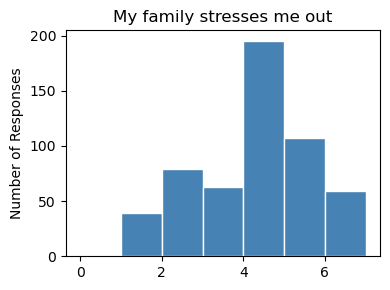

In [95]:
#Create a histogram to show the distribution of responses for the question 'family_stress'
import matplotlib.pyplot as plt     # import appropriate library

# create the histogram
family_df.plot(kind='hist', y='stress',
                  figsize=(4, 3),
                  title='My family stresses me out',
                  ylabel='Number of Responses',
                  bins=7,
                  range=(0, 7),
                  color='steelblue',
                  edgecolor='white',
                  legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

* Near 200 students somewhat agreed that their families stressed them out.
* A bit over 50 students strongly agreed that their families stressed them out.
* Almost 50 students strongly disagreed that their families stressed them out.
* The distribution is slightly skewed to the right.

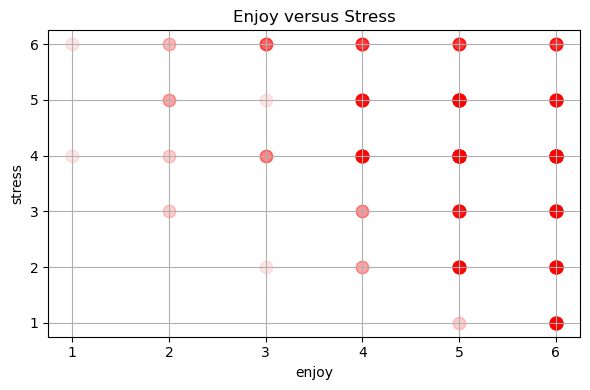

In [96]:
#Create a scatter plot to show the relationship between the responses to the questions 'family_enjoy' and 'family_stress'
import matplotlib.pyplot as plt     # import appropriate library

# create a scatter plot
family_df.plot(kind='scatter',             #Indicate the kind of plot to be generated
        x='enjoy',            #Identify the column for the x_axis
        y='stress',             #Identify the column for the y-axis
        figsize=(6, 4),             #Set up the width and height of the graph
        title='Enjoy versus Stress',  #Set up the title of the graph
        s=80,                       #Indicate the size of each dot
        alpha=0.1,                  #Indicate the level of transparency
        color='red',                #Indicate the color for the dots
        grid=True                   #Decide whether to use grid
)

plt.tight_layout()                  #adjust spacing to avoid overlap
plt.show()                          #show the chart

## Data Preparation

In [97]:
# Remove the family_ prefix
family_df.columns = family_df.columns.str.removeprefix('family_')
# Recode responses for negatively worded questions
r_columns = ['stress', 'secrets', 'fight']
family_df[r_columns] = 7 - family_df[r_columns]
# Create a column to hold the average among the columns
# Note that I didn't specify the columns before calling the mean function.
# This is because I want to use all columns in the dataset.
family_df['mean'] = family_df.mean(axis=1)

### Combining columns from multiple DataFrame

In [98]:
#source of data: https://www.pewresearch.org/social-trends/2014/04/10/next-america/#the-generational-divide
import pandas as pd
population_data = {
    'Year':[1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060],
    'White':[.85, .83, .80, .76, .69, .64, .60, .55, .51, .47, .43],
    'Black': [.10, .11, .12, .12, .12, .12, .13, .13, .13, .13, .13],
    'Hispanic': [.04, .05, .06, .09, .13, .16, .19, .22, .25, .28, .31],
    'Asian': [.01, .01, .02, .03, .04, .05, .06, .06, .07, .08, .08],
    'Others': [.00, .00, .01, .01, .02, .03, .03, .04, .04, .05, .06]
    }
population_df = pd.DataFrame(population_data)
population_df

,Year,White,Black,Hispanic,Asian,Others
0,1960,0.8,0.1,0.0,0.0,0.0
1,1970,0.8,0.1,0.1,0.0,0.0
2,1980,0.8,0.1,0.1,0.0,0.0
3,1990,0.8,0.1,0.1,0.0,0.0
4,2000,0.7,0.1,0.1,0.0,0.0
5,2010,0.6,0.1,0.2,0.1,0.0
6,2020,0.6,0.1,0.2,0.1,0.0
7,2030,0.6,0.1,0.2,0.1,0.0
8,2040,0.5,0.1,0.2,0.1,0.0
9,2050,0.5,0.1,0.3,0.1,0.1


In [99]:
#Creating a DataFrame object to include data from family_df['mean']
#and two non-gender categorical columns from the demographics section
family_by_demo_data = {'classstanding': raw_df['demo_classstanding'].copy(),
                       'employed': raw_df['demo_employed01'].copy(),
                       'family_satisfaction': family_df['mean'].copy()
                       }

family_by_demo_df = pd.DataFrame(family_by_demo_data)

pd.options.display.float_format = '{:.2f}'.format
family_by_demo_df.head()

,classstanding,employed,family_satisfaction
0,2,1.00,4.29
1,3,1.00,4.86
2,3,2.00,5.14
3,2,2.00,4.71
4,2,2.00,4.43


In [104]:
family_by_gender_data = {'gender':raw_df['demo_gender'].copy(),
                  'family_satisfaction':family_df['mean'].copy()}
family_by_gender_df = pd.DataFrame(family_by_gender_data)
pd.options.display.float_format = '{:.2f}'.format
family_by_gender_df.head()

,gender,family_satisfaction
0,1,4.29
1,2,4.86
2,1,5.14
3,2,4.71
4,2,4.43


## Seaborn

In [100]:
import seaborn as sns

### sns.histplot

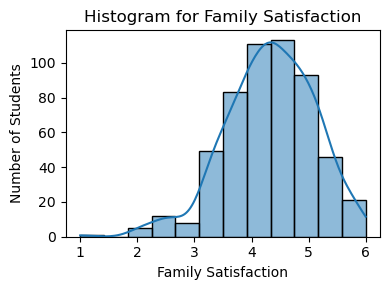

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Create a histogram to show the distribution of responses for the question 'family_satisfaction'
plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=family_by_gender_df, x='family_satisfaction', bins=12, kde=True)

plt.tight_layout()
plt.show()

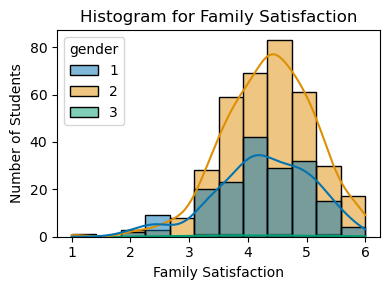

In [106]:
#Create a histogram to show the distribution of responses for the question 'family_satisfaction
# Use plt functions to set up the figure size, title, and labels
plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=family_by_gender_df,  # specify the DataFrame object
             x='family_satisfaction',   # identify a numeric column
             hue='gender',              # identify a categorical column
             palette='colorblind',      # specify the color palette to be used
             bins=12,                   # specify the number of bins
             kde=True)                  # to show the curve

plt.tight_layout()
plt.show()

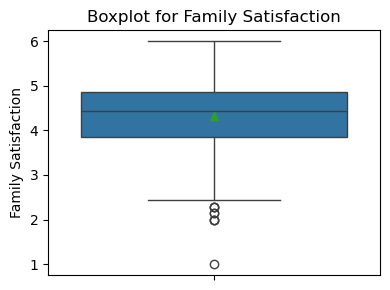

In [107]:
#Create a boxplot to show the distribution of responses for the question 'family_satisfaction
plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')

sns.boxplot(data=family_by_gender_df,
            y='family_satisfaction',
            showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

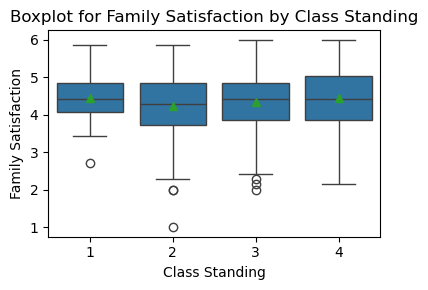

In [108]:
#Create a boxplot to show the distribution of responses for the question 'family_satisfaction' by class standing
plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction by Class Standing')
plt.ylabel('Family Satisfaction')
plt.xlabel('Class Standing')

sns.boxplot(data=family_by_demo_df,
            y='family_satisfaction',
            x='classstanding',
            showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

In [ ]:
#Create a boxplot to show the distribution of responses for the question 'family_satisfaction' by employment status
plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction by Employment')
plt.ylabel('Family Satisfaction')
plt.xlabel('Employment')

sns.boxplot(data=family_by_demo_df,
            y='family_satisfaction',
            x='employed',
            showmeans=True)

plt.tight_layou

The medians for family satisfaction across class standings is around 4.3-4.5 and for employment it is similar. The median for employed students appear slightly higher than the non-employed students. The spread of data are fairly similar across groups which suggest that the middle 50% of family satisfaction are distreibuted similarily. The whiskers also have similar ranges for most groups, between 3 and 6 indicating that most students report middle to high levels of family satisfaction. There are some low outliers in some groups in some class standings and non-employed students. These outliers mean some students have reported low family satisfaction compared to the majority of reporting high levels of family satisfaction.

## Data Preparation

In [109]:
#Create a DataFrame object to hold only columns from the family satisfaction and deviance sections
dev_fam_df = raw_df.filter(regex='^deviance|^family').copy()

#Recode responses for negatively worded questions
r_columns = ['deviance_play', 'deviance_cautious', 'family_stress', 'family_secrets', 'family_fight']
dev_fam_df[r_columns] = 7 - dev_fam_df[r_columns]

#Determine and save section means
family_columns = dev_fam_df.filter(regex='^family')
deviance_columns = dev_fam_df.filter(regex='^deviance')
dev_fam_df['family_mean'] = family_columns.mean(axis = 1)
dev_fam_df['deviance_mean'] = deviance_columns.mean(axis = 1)

# Create a new DataFrame to combine section means with demographic data
data = {'gender':raw_df['demo_gender'].copy(),
        'relationship': raw_df['demo_relationshipstatus01'].copy(),
        'children': raw_df['demo_children'],
        'classstanding': raw_df['demo_classstanding'],
        'past_employed': raw_df['demo_employed01'],
        'current_employed': raw_df['demo_employed02'],
        'politics': raw_df['demo_politics'],
        'religion': raw_df['demo_religion'],
        'family_satisfaction': dev_fam_df['family_mean'],
        'deviance': dev_fam_df['deviance_mean']}
df = pd.DataFrame(data)

#Replace numbers with text for categorical columns
gender_map = {1:'Male', 2:'Female', 3:'Other'}
df['gender'] = df['gender'].replace(gender_map)
df['relationship'] = df['relationship'].replace({1:'No', 2:'Yes'})
yes_no_columns = ['children', 'past_employed', 'current_employed']
yes_no_map = {1:'Yes', 2:'No'}
df[yes_no_columns] = df[yes_no_columns].replace(yes_no_map)
class_labels = ['First-year', 'Sophomore', 'Junior', 'Senior']
class_bins = [0, 1, 2, 3, 4]
df['classstanding'] = pd.cut(df['classstanding'],
                             bins=class_bins,
                             labels=class_labels,
                             right=True)
politics_labels = ['conservative', 'moderate', 'liberal']
politics_bins = [0, 2, 4, 6]
df['politics'] = pd.cut(df['politics'],
                             bins=politics_bins,
                             labels=politics_labels,
                             right=True)

religion_labels = ['Yes', 'No']
religion_bins = [0, 3, 6]
df['religion'] = pd.cut(df['religion'],
                             bins=religion_bins,
                             labels=religion_labels,
                             right=True)


df.head(10)

,gender,relationship,children,classstanding,past_employed,current_employed,politics,religion,family_satisfaction,deviance
0,Male,No,No,Sophomore,Yes,Yes,NaN,No,4.29,3.62
1,Female,Yes,No,Junior,Yes,Yes,moderate,No,4.86,3.12
2,Male,No,No,Junior,No,No,moderate,Yes,5.14,3.12
3,Female,No,No,Sophomore,No,No,moderate,No,4.71,3.50
4,Female,No,No,Sophomore,No,No,moderate,Yes,4.43,3.62
5,Female,No,No,Junior,Yes,Yes,NaN,Yes,3.71,3.12
6,Male,Yes,No,Junior,Yes,Yes,conservative,Yes,4.71,2.75
7,Female,No,No,Senior,Yes,Yes,liberal,Yes,4.71,3.75
8,Female,Yes,No,Junior,Yes,Yes,moderate,Yes,5.00,3.38
9,Male,Yes,No,Senior,Yes,Yes,liberal,No,4.00,3.12


### groupby

In [115]:
#Find out the number of non-NaN values for the family satisfaction column for each gender
df.groupby('gender')['family_satisfaction'].count()

gender
Female    362
Male      176
Other       4
Name: family_satisfaction, dtype: int64

In [116]:
#Find out the standard deviations for the family satisfaction column for each gender
df.groupby('gender')['family_satisfaction'].std()

gender
Female   0.76
Male     0.82
Other    0.97
Name: family_satisfaction, dtype: float64

In [117]:
#Find out the means for the family satisfaction column for each gender  
df.groupby('gender')['family_satisfaction'].mean()

gender
Female   4.36
Male     4.26
Other    4.21
Name: family_satisfaction, dtype: float64

### agg

In [118]:
#Find out the count, mean, standard deviation, minimum, maximum, and median for the family satisfaction column for each gender
df.groupby('gender')['family_satisfaction'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])

,count,mean,std,min,max,median
gender,,,,,,
Female,362,4.36,0.76,1.00,6.00,4.43
Male,176,4.26,0.82,2.00,5.86,4.29
Other,4,4.21,0.97,3.14,5.43,4.14


* 362 female students and 176 male students answered the family satisfaction section.
* Only 4 students marked other for gender on their survey. With such a small number, it would be hard to generalize any findings for this group.
* The lowest level of family satisfaction for female students was 1 while the the highest level was 6.
* The median and average family satisfaction for female students were slightly higher than those for male students. Meanwhile, responses from female students varied slightly less than responses from male students.

## Pivot Tables

In [123]:
#Pivot the family_satisfaction column using the gender column to perform the count action.
pivot_by_gender = df.pivot_table(values='family_satisfaction',
              index='gender',
              aggfunc = 'count')
pivot_by_gender

,family_satisfaction
gender,
Female,362
Male,176
Other,4


In [124]:
#Pivot the family_satisfaction and deviance columns using the gender column to perform the mean action.
pivot_by_gender_class = df.pivot_table(values=['family_satisfaction', 'deviance'],
                        index='gender',
                        aggfunc = 'mean',
                        observed=True)
pivot_by_gender_class

,deviance,family_satisfaction
gender,,
Female,3.14,4.36
Male,3.44,4.26
Other,3.50,4.21


* average deviance for female is lower than male
* average family satisfaction for female is higher than male

In [125]:
#Pivot the family_satisfaction and deviance columns using the gender and classstanding columns to perform the mean action.
pivot_by_gender_class = df.pivot_table(values=['family_satisfaction', 'deviance'],
                        index=['gender', 'classstanding'],
                        aggfunc = 'mean',
                        observed=True)
pivot_by_gender_class

deviance  family_satisfaction
gender classstanding                               
Female First-year         2.98                 4.55
       Sophomore          3.16                 4.25
       Junior             3.11                 4.37
       Senior             3.27                 4.53
Male   First-year         3.38                 4.35
       Sophomore          3.26                 4.21
       Junior             3.55                 4.25
       Senior             3.48                 4.32
Other  First-year         4.38                 3.86
       Sophomore          4.12                 3.14
       Junior             2.75                 4.93

* For female students, first year respondents had lowest average deviance and highest average family satisfaction.
* For male students, sophomore respondents had lowest average deviance and lowest average family satisfaction.
* Female students had higher average family satisfaction than male in every class standing.

In [127]:
#Pivot the family_satisfaction and deviance columns using the gender and classstanding columns to perform the mean and standard deviation actions.
pivot_by_gender_class = df.pivot_table(values=['family_satisfaction', 'deviance'],
                        index=['gender', 'classstanding'],
                        aggfunc = ['mean', 'std'],
                        observed=True)
pivot_by_gender_class

mean                          std                    
                     deviance family_satisfaction deviance family_satisfaction
gender classstanding                                                          
Female First-year        2.98                4.55     0.60                0.70
       Sophomore         3.16                4.25     0.70                0.80
       Junior            3.11                4.37     0.66                0.72
       Senior            3.27                4.53     0.66                0.80
Male   First-year        3.38                4.35     0.76                0.60
       Sophomore         3.26                4.21     0.71                0.88
       Junior            3.55                4.25     0.77                0.81
       Senior            3.48                4.32     0.60                0.84
Other  First-year        4.38                3.86      NaN                 NaN
       Sophomore         4.12                3.14      NaN                 NaN
       Junior            2.75                4.93     0.18                0.71

## Analysis of Variance (ANOVA)

## one-way ANOVA

In [128]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

## Family satisfaction and gender

### Visualization

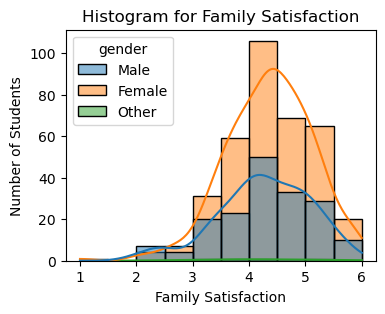

In [ ]:
#Create a histogram to show the distribution of responses for the question 'family_satisfaction' by gender
plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=df, x='family_satisfaction', hue='gender', bins=10, kde=True)

plt.show()

The histogram shows a normal distribution of family satisfaction but there exists some difference between female and male.

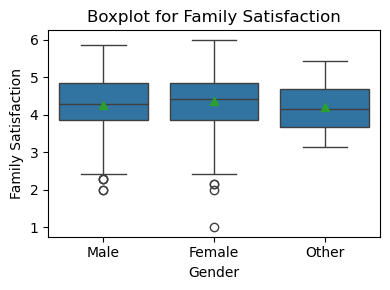

In [130]:
#Create a boxplot to show the distribution of responses for the question 'family_satisfaction'
plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

sns.boxplot(data=df, y='family_satisfaction', x='gender', showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

The box plot shows the median/mean for female is a bit higher than the median/mean for male.

In [132]:
#Find out the mean for the family satisfaction column for each gender
fam_gender_group = df.groupby('gender')['family_satisfaction'].mean()
fam_gender_group

gender
Female   4.36
Male     4.26
Other    4.21
Name: family_satisfaction, dtype: float64

In [137]:
#Pivot the family_satisfaction column using the gender column to perform the mean action.
fam_gender_pivot = df.pivot_table(values='family_satisfaction',
                        index='gender',
                        aggfunc = 'mean',
                        observed=True)
fam_gender_df = fam_gender_pivot.reset_index()
fam_gender_df

,gender,family_satisfaction
0,Female,4.36
1,Male,4.26
2,Other,4.21


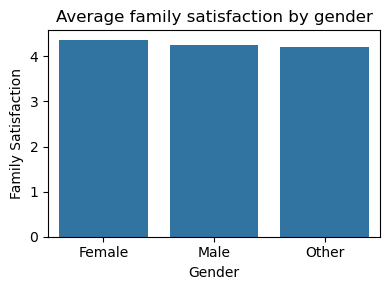

In [138]:
#Create a bar plot to show the average family satisfaction for each gender
plt.figure(figsize=(4, 3))
sns.barplot(data=fam_gender_df, y='family_satisfaction', x='gender')
plt.title('Average family satisfaction by gender')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

plt.tight_layout()
plt.show()

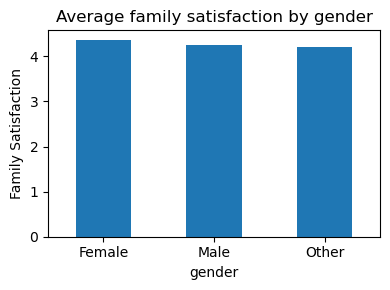

In [139]:
#Create a bar plot to show the average family satisfaction for each gender
fam_gender_df.plot(kind='bar',
        x='gender',
        y='family_satisfaction',
        figsize=(4, 3),
        title='Average family satisfaction by gender',
        ylabel='Family Satisfaction',
        rot=0,
        legend=False)

plt.tight_layout()
plt.show()

### Null Hypothesis

Here is a null hypothesis that can be tested using ANOVA:

* There is NO DIFFERENCE of family satisfaction among groups of different gender.

To perform an ANOVA Test on the above mentioned null hypothesis:

* gender would be the independent, categorical variable
* family_satisfaction would be the dependent, quantitative variable.

### Perform ANOVA

In [140]:
#Perform an ANOVA test to find out if there is a significant difference in family satisfaction among different
fam_gender_model = ols(formula='family_satisfaction ~ C(gender)', data=df).fit()
fam_gender_anova = anova_lm(fam_gender_model, typ=2)
print(fam_gender_anova)

           sum_sq     df    F  PR(>F)
C(gender)    1.17   2.00 0.96    0.38
Residual   329.52 539.00  NaN     NaN


### Interprete ANOVA Table

There are several key elements of an ANOVA table. First, let's look at the two rows of the table.
* The C(gender) row measures variability due to the interaction between the groups. In this case, between different genders.
* The Residual row measures variability within each category group. In this case, within each gender.

Now, let's look at the columns of the table:
* sum_sq is for sum of squares. It measures variability. C(gender) sum_sq measures variability between gender groups. Residual sum_sq measures variability within groups (i.e. unexplained variation)
* df is for degree of freedom. C(gender) df is the number of different gender groups minus 1. Residual df is the total observation minus the number of groups.
* F: This is also commonly referred to as the F-statistics. It is the ratio of the mean square between the groups to the mean square within the groups. A higher F-value indicates a greater degree of variance between the group means relative to the variance within the groups.
* PR(>F): This is also commonly referred to as the p-value. It measures the probability of observing an F-statistic more extreme than the one calculated from the data.

The p-value above is 0.384662, indicating the difference in group means is NOT SIGNIFICANT at common threshold of 0.05. Therefore, we fail to reject the null hypothesis and conclude that there is NO STRONG EVIDENCE that gender is associated with differences in differences in family satisfaction.

## Deviance by class standing

### Visualization

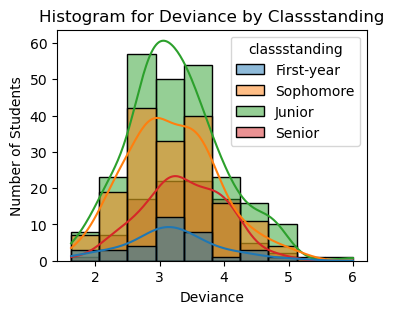

In [141]:
#Create a histogram to show the distribution of responses for the question 'deviance' by classstanding
plt.figure(figsize=(4, 3))
plt.title('Histogram for Deviance by Classstanding')
plt.ylabel('Number of Students')
plt.xlabel('Deviance')

sns.histplot(data=df, x='deviance', hue='classstanding', bins=10, kde=True)

plt.show()

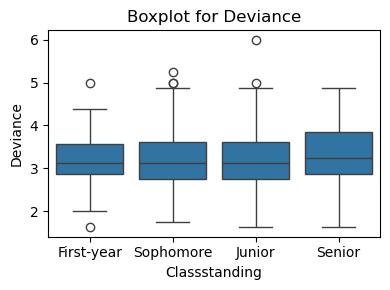

In [142]:
#Create a boxplot to show the distribution of responses for the question 'deviance' by classstanding
plt.figure(figsize=(4, 3))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Classstanding')

sns.boxplot(data=df, y='deviance', x='classstanding')

plt.tight_layout() 
plt.show()

In [ ]:
#Find out the mean for the deviance column for each class standing
dev_class_group = df.groupby('classstanding', observed=True)['deviance'].mean().reset_index()
dev_class_group

,classstanding,deviance
0,First-year,3.17
1,Sophomore,3.20
2,Junior,3.24
3,Senior,3.35


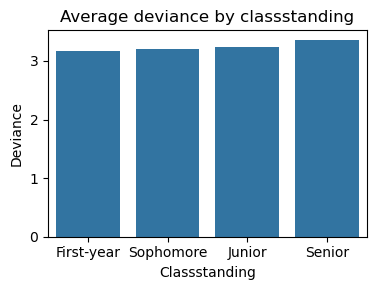

In [144]:
#Pivot the deviance column using the classstanding column to perform the mean action.
plt.figure(figsize=(4, 3))
sns.barplot(data=dev_class_group, y='deviance', x='classstanding')
plt.title('Average deviance by classstanding')
plt.ylabel('Deviance')
plt.xlabel('Classstanding')

plt.tight_layout()
plt.show()

### Null Hypothesis

State null hypothesis that can be tested using ANOVA. Identify the independent, categorical variable and the dependent, quantitative variable.

There is no difference in deviance among different class standing groups.
* classstanding would be an independent, categorical variable.
* deviance would be a dependent, quantitative variable

### Perform ANOVA

In [145]:
# Use the ols function to prepare a linear model.
dev_class_model = ols(formula='deviance ~ C(classstanding)', data=df).fit()
# Use the anova_lm function to perform the test
dev_class_anova = anova_lm(dev_class_model, typ=2)
# Show the resulting ANOVA table.
print(dev_class_anova)

                  sum_sq     df    F  PR(>F)
C(classstanding)    1.76   3.00 1.19    0.31
Residual          266.29 539.00  NaN     NaN


### Interprete ANOVA Table

The p-value is not less than 0.5, indicating that there is not a significant difference in family satisfaction among class standing groups.

## two-way ANOVA

## Deviance by gender and class standing

### Visualization

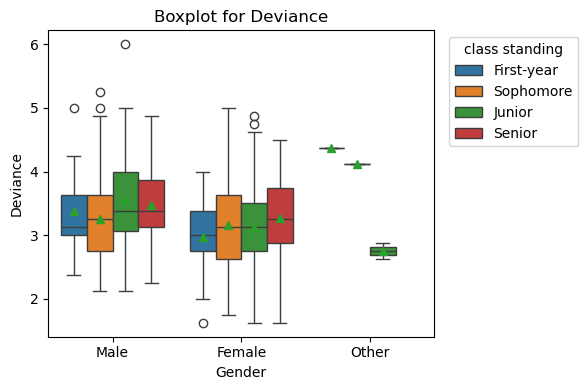

In [146]:
#Create a boxplot to show the distribution of responses for the question 'deviance' by gender and class standing
plt.figure(figsize=(6, 4))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Gender')

sns.boxplot(data=df,
            y='deviance',
            x='gender',
            hue='classstanding',
            showmeans=True)

plt.legend(title='class standing',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

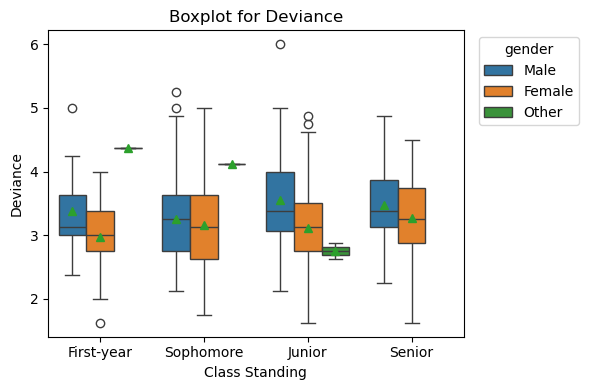

In [147]:
#Create a boxplot to show the distribution of responses for the question 'deviance' by gender and class standing
plt.figure(figsize=(6, 4))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Class Standing')

sns.boxplot(data=df,
            y='deviance',
            hue='gender',
            x='classstanding',
            showmeans=True)

plt.legend(title='gender',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [148]:
#Find out the mean for the deviance column for each gender and class standing
dev_gc_group = df.groupby(['gender', 'classstanding'], observed=True)['deviance'].mean().reset_index()
dev_gc_group

,gender,classstanding,deviance
0,Female,First-year,2.98
1,Female,Sophomore,3.16
2,Female,Junior,3.11
3,Female,Senior,3.27
4,Male,First-year,3.38
5,Male,Sophomore,3.26
6,Male,Junior,3.55
7,Male,Senior,3.48
8,Other,First-year,4.38
9,Other,Sophomore,4.12


In [149]:
#Pivot the deviance column using the gender and classstanding columns to perform the mean action.
dev_gc_pivot = df.pivot_table(values='deviance',
                              index=['gender', 'classstanding'],
                              aggfunc='mean',
                              observed=True).reset_index()
dev_gc_pivot

,gender,classstanding,deviance
0,Female,First-year,2.98
1,Female,Sophomore,3.16
2,Female,Junior,3.11
3,Female,Senior,3.27
4,Male,First-year,3.38
5,Male,Sophomore,3.26
6,Male,Junior,3.55
7,Male,Senior,3.48
8,Other,First-year,4.38
9,Other,Sophomore,4.12


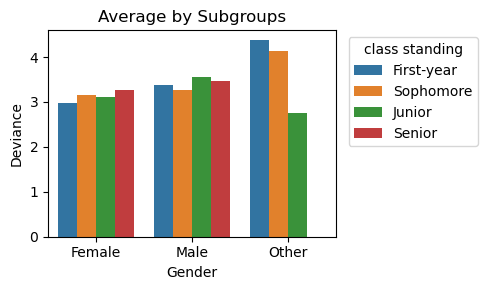

In [150]:
#Create a bar plot to show the average deviance for each gender and class standing
plt.figure(figsize=(5, 3))
sns.barplot(data=dev_gc_group, y='deviance', x='gender', hue='classstanding')
plt.title('Average by Subgroups')
plt.ylabel('Deviance')
plt.xlabel('Gender')

plt.legend(title='class standing',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

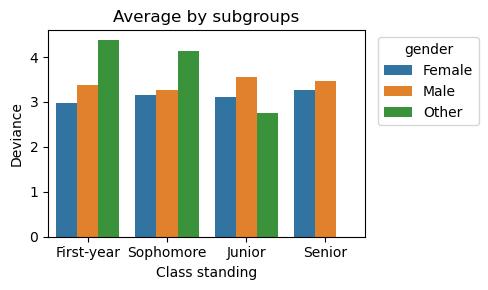

In [151]:
#Create a bar plot to show the average deviance for each gender and class standing
plt.figure(figsize=(5, 3))
sns.barplot(data=dev_gc_group, y='deviance', hue='gender', x='classstanding')
plt.title('Average by subgroups')
plt.ylabel('Deviance')
plt.xlabel('Class standing')

plt.legend(title='gender',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


### Null Hypothesis

or each test, we specify three null hypotheses:

There is no difference of deviance among different genders.
There is no difference of deviance among different class standings.
The effect of gender on deviance does not depend on class standings.
To perform an ANOVA Test on the above mentioned null hypothesis:

gender and classstandingwould be the independent, categorical variable
deviance would be the dependent, quantitative variable.

### Perform ANOVA

In [158]:
#Perform a two-way ANOVA test to find out if there is a significant difference in deviance
df_clean = df[df['gender'] != 'Other']

deviance_model = ols('deviance ~ C(gender) * C(classstanding)', data=df_clean).fit()
deviance_anova = anova_lm(deviance_model, typ=2)

print(deviance_anova)

                            sum_sq     df     F  PR(>F)
C(gender)                     9.77   1.00 20.68    0.00
C(classstanding)              1.53   3.00  1.08    0.36
C(gender):C(classstanding)    2.60   3.00  1.83    0.14
Residual                    251.02 531.00   NaN     NaN


### Interprete ANOVA Table

Main Effect: gender
* p = 0.000007
* There is a significant difference in deviance between genders, averaged across all class standings. Gender matters, regardless of class standing.

Main Effect: classstanding
* p = 0.36
* There is no evidence that deviance differs by class standing, when averaging across gender. Any observed differences among First-year, sophomore, juniors, and seniors could be reasonably be attributed to random variation.

Interaction: gender x classstanding
* p = 0.14 No interaction → the gender difference is fairly consistent across all class standings. The observed differences in gender gaps across class standings are not large enough, relative to within-group variability, to conclude that the gender effect truly depends on class standing.

sum_sq: The sum of squares measure how spread out the data are around the mean/average. ANOVA answers how much of the total variability we can attribute to each source.
* Gender sum_sq measures how much variability is explained by differences between gender means, ignoring class standing.
* Class standing sum_sq measures how much variability is explained by differences among class standing means, ignoring gender.
* Interaction sum_sq measures how much additional variability is explained by allowing the gender effect to differ across class standings.
* Residual sum_sq indicates how much variability is NOT explained by the model.

From the above result, we can see that residual sum_sq (251) is much larger than the total of the other sum_sq (9.78 + 1.53 + 2.59), inicating that unexplained variability is much larger.

## Family satisfaction by children and gender

### Visualization

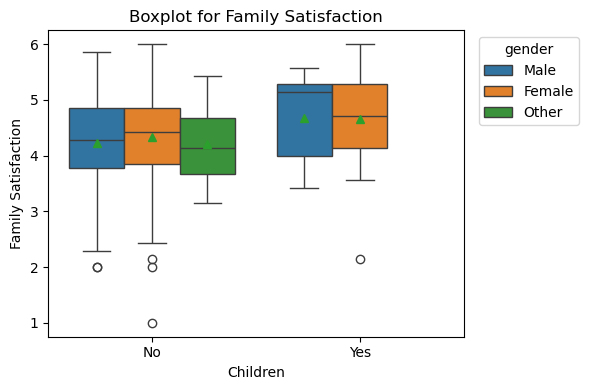

In [ ]:
#Creating a boxplot to show the distribution of responses for the question 'family_satisfaction' by gender and children
plt.figure(figsize=(6, 4))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')
plt.xlabel('Children')

sns.boxplot(data=df,
            y='family_satisfaction',
            x='children',
            hue='gender',
            showmeans=True)

plt.legend(title='gender',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

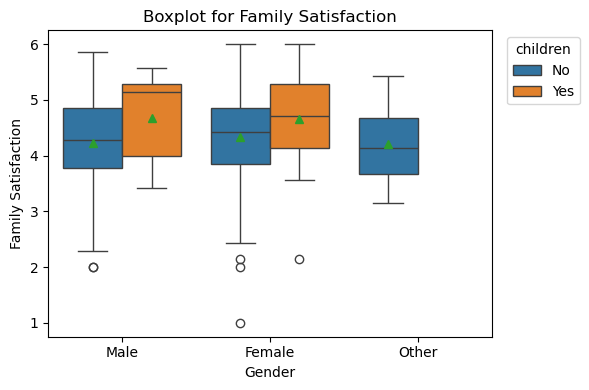

In [160]:
#Creating a boxplot to show the distribution of responses for the question 'family_satisfaction' by gender and children
plt.figure(figsize=(6, 4))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

sns.boxplot(data=df,
            y='family_satisfaction',
            x='gender',
            hue='children',
            showmeans=True)

plt.legend(title='children',
           loc='upper left',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout() 
plt.show()

In [ ]:
#Find out the mean for the family satisfaction column for each combination of gender and children
fam_cg_group = df.groupby(['children', 'gender'], observed=True)['family_satisfaction'].mean().reset_index()
fam_cg_group

,children,gender,family_satisfaction
0,No,Female,4.33
1,No,Male,4.23
2,No,Other,4.21
3,Yes,Female,4.66
4,Yes,Male,4.67


In [ ]:
#Pivot the family_satisfaction column using the children and gender columns to perform the mean action.
fam_cg_pivot = df.pivot_table(values='family_satisfaction',
                              index=['children', 'gender'],
                              aggfunc='mean',
                              observed=True).reset_index()
fam_cg_pivot

,children,gender,family_satisfaction
0,No,Female,4.33
1,No,Male,4.23
2,No,Other,4.21
3,Yes,Female,4.66
4,Yes,Male,4.67


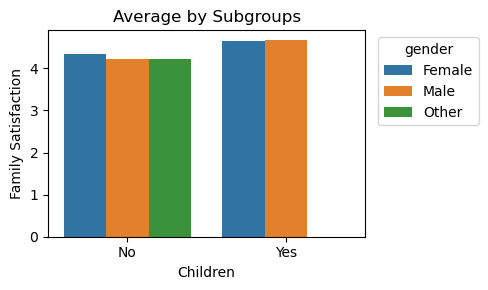

In [163]:
#Creating a bar plot to show the average family satisfaction for each combination of gender and children
plt.figure(figsize=(5, 3))
sns.barplot(data=fam_cg_group, y='family_satisfaction', x='children', hue='gender')
plt.title('Average by Subgroups')
plt.ylabel('Family Satisfaction')
plt.xlabel('Children')

plt.legend(title='gender',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

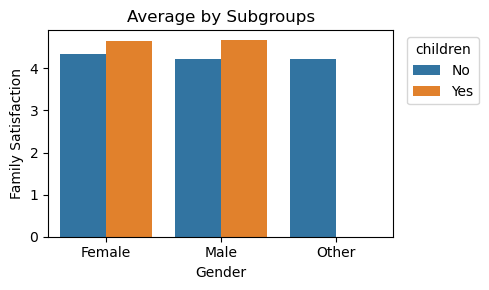

In [164]:
#Create a bar plot to show the average family satisfaction for each combination of gender and children
plt.figure(figsize=(5, 3))
sns.barplot(data=fam_cg_group, y='family_satisfaction', x='gender', hue='children')
plt.title('Average by Subgroups')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

plt.legend(title='children',
           bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Null Hypothesis

1. There is no difference in family satisfaction among different children categories.
2. There is no difference of family satisfaction among different genders.
3. The effect of childrem on family satisfaction does not depend on gender.

To perform an ANOVA Test on the above mentioned null hypothesis:
* children and gender would be the independent, categorical variable
* family_satisfaction would be the dependent, quantitative variable.

### Perform ANOVA

In [167]:
#Perform a two-way ANOVA test to find out if there is a significant difference in family satisfaction among different combinations of gender and children
df_clean = df[df['gender'] != 'Other']
# Use the ols function to prepare a linear model.
family_model = ols(formula='family_satisfaction ~ C(children) + C(gender) + C(children) : C(gender)',
                            data=df_clean).fit()
# Use the anova_lm function to perform the test
family_anova = anova_lm(family_model, typ=2)
# Show the resulting ANOVA table.
print(family_anova)

                       sum_sq     df    F  PR(>F)
C(children)              5.36   1.00 8.92    0.00
C(gender)                1.03   1.00 1.72    0.19
C(children):C(gender)    0.11   1.00 0.19    0.66
Residual               320.38 533.00  NaN     NaN


### Interprete ANOVA Table

Main Effect: gender
* 0.002943
* There is a significant difference in family satisfaction among children categories

Main Effect: classstanding
* p = 0.190446
* There is no evidence that family satisfaction differs by gender.

Interaction: gender x classstanding
* p = 0.664304 No interaction → The effact of children appears to be consistent across genders

sum_sq: The sum of squares tells us how much variability there is in each part of model.
* children sum_sq measures how much variability is explained by differences among children categories
* gender sum_sq measures how much variability is explained by gender differences
* interaction sum_sq measures how much additional variability is explained by the combination of children and gender
* residual sum_sq indicates how much variability is NOT explained by the model.

From the above result, we can see that residual sum_sq (320) is much larger than the total of the other sum_sq (5.36 + 1.03 + 0.11), inicating that unexplained variability is much larger.